# House Prices Prediction


In [1]:
# Module import
import os
import sys
import seaborn as sns
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

## Import of Datasets

The Ames Housing Dataset contains information on residential property sales in Ames, Iowa, USA, covering the period from 2006 to 2010. The dataset is publicly available through Kaggle at:

https://www.kaggle.com/competitions/home-data-for-ml-course/overview

The data consists of three files: train.csv, test.csv, and data_description.txt. The train.csv file includes the target variable SalePrice, while the test.csv file contains the same feature set without the target variable. The data_description.txt file provides detailed explanations of all variables and is included at the end of this notebook to assist readers in understanding the dataset.

Train_ds:

In [2]:
# importing the dataset
Filename="train.csv"
Datadir="../prices/Datasets/"
train_ds=pd.read_csv(Datadir + Filename, header=0, index_col="Id")
train_ds.head()


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Test_ds:

In [3]:
Filename = "test.csv"
Datadir="../prices/Datasets/"
test_ds = pd.read_csv(Datadir + Filename, header=0, index_col="Id")
test_ds.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## Information about Datasets
Train_ds:

In [4]:
train_ds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

Test_ds:

In [5]:
test_ds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1459 entries, 1461 to 2919
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   Alley          107 non-null    object 
 6   LotShape       1459 non-null   object 
 7   LandContour    1459 non-null   object 
 8   Utilities      1457 non-null   object 
 9   LotConfig      1459 non-null   object 
 10  LandSlope      1459 non-null   object 
 11  Neighborhood   1459 non-null   object 
 12  Condition1     1459 non-null   object 
 13  Condition2     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearB

Train_ds contains 1460 rows (instances) and 80 columns (variables) including the target row 'SalePrice', while test_ds contains 1459 rows (instances) and 79 columns (not the target column 'SalePrice). Both datasets cover the same period of year 2006-2010. 

In [6]:
train_sold_counts=train_ds['YrSold'].value_counts()
test_sold_counts=test_ds['YrSold'].value_counts()
display("Train_ds Sold Houses", train_sold_counts)
display("Test_ds Sold Houses", test_sold_counts)

'Train_ds Sold Houses'

2009    338
2007    329
2006    314
2008    304
2010    175
Name: YrSold, dtype: int64

'Test_ds Sold Houses'

2007    363
2008    318
2009    309
2006    305
2010    164
Name: YrSold, dtype: int64

## Data Cleaning
I need to create a copy of train_ds to be cleaned and used in exploratory data analysis.

In [7]:
eda_ds=train_ds.copy()

Checking datatypes in combined_ds.

In [8]:
num_vars = eda_ds.select_dtypes(include=[np.number]).columns.tolist()
float_vars = eda_ds.select_dtypes(include=[float]).columns.tolist()
cat_vars = eda_ds.select_dtypes(include=[object]).columns.tolist()

print("Numerical Variables:", num_vars)
print("Float Variables:", float_vars)
print("Categorical Variables:", cat_vars)

Numerical Variables: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
Float Variables: ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
Categorical Variables: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'Centra

Some variables are not in proper datatype, for example categorical values in numerical datatypes. For simplicity, I am going to change float variable to integer variables.

Missing values:

In [9]:
missing_train = eda_ds.isnull().sum().sort_values(ascending=False)
missing_train[missing_train > 0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtExposure      38
BsmtFinType2      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
MasVnrType         8
Electrical         1
dtype: int64

In [10]:
# Numeric imputation and dtype conversion
#  LotFrontage: median 
eda_ds['LotFrontage'] = eda_ds['LotFrontage'].fillna(eda_ds['LotFrontage'].median())

# These numeric fields: fill missing with 0 (meaning "none" for area/count features in this dataset)
num_fill_zero = [
    'MasVnrArea', 'GarageYrBlt', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea',
    'YearBuilt', 'YearRemodAdd'
]
eda_ds[num_fill_zero] = eda_ds[num_fill_zero].fillna(0)


#  Convert selected fields to the intended dtypes
int_to_strings = ['MSSubClass', 'MoSold']  # treat as nominal categories

float_to_int = ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
                'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
                'GarageCars', 'GarageArea', 'GarageYrBlt', 'YrSold']

eda_ds[float_to_int] = eda_ds[float_to_int].astype('int64')
eda_ds[int_to_strings] = eda_ds[int_to_strings].astype(str)


In [11]:
# - Features where NA is better treated as "most frequent" (mode)
mode_fill = ['MSZoning', 'Utilities', 'Functional', 'Exterior1st', 'Exterior2nd',
             'SaleType', 'KitchenQual', 'Electrical','PoolQC', 'MiscFeature', 
             'Alley', 'Fence', 'FireplaceQu', 'GarageFinish', 'GarageQual',
             'GarageType', 'GarageCond', 'BsmtExposure', 'BsmtCond',
             'BsmtQual', 'BsmtFinType2', 'BsmtFinType1' ]
for col in mode_fill:
    if col in eda_ds.columns:
        eda_ds[col] = eda_ds[col].fillna(eda_ds[col].mode(dropna=True)[0])

# - Masonry veneer type: "None" when missing
if 'MasVnrType' in eda_ds.columns:
    eda_ds['MasVnrType'] = eda_ds['MasVnrType'].fillna('None')

Final check:

In [12]:
eda_ds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSSubClass     1460 non-null   object
 1   MSZoning       1460 non-null   object
 2   LotFrontage    1460 non-null   int64 
 3   LotArea        1460 non-null   int64 
 4   Street         1460 non-null   object
 5   Alley          1460 non-null   object
 6   LotShape       1460 non-null   object
 7   LandContour    1460 non-null   object
 8   Utilities      1460 non-null   object
 9   LotConfig      1460 non-null   object
 10  LandSlope      1460 non-null   object
 11  Neighborhood   1460 non-null   object
 12  Condition1     1460 non-null   object
 13  Condition2     1460 non-null   object
 14  BldgType       1460 non-null   object
 15  HouseStyle     1460 non-null   object
 16  OverallQual    1460 non-null   int64 
 17  OverallCond    1460 non-null   int64 
 18  YearBuilt      1460 non-null

## EDA
Exploratory Data Analysis (EDA) is conducted to gain insight into the distributions and characteristics of the dataset prior to modeling. Visualization techniques play a key role in identifying skewness, sparsity, outliers, and potential data quality issues.

For this purpose, histograms are used to analyze numerical variables, and bar plots are used to examine categorical variables.

The following histograms summarize the distributions of the numerical features and highlight key patterns relevant for feature engineering and model selection.

### Histograms

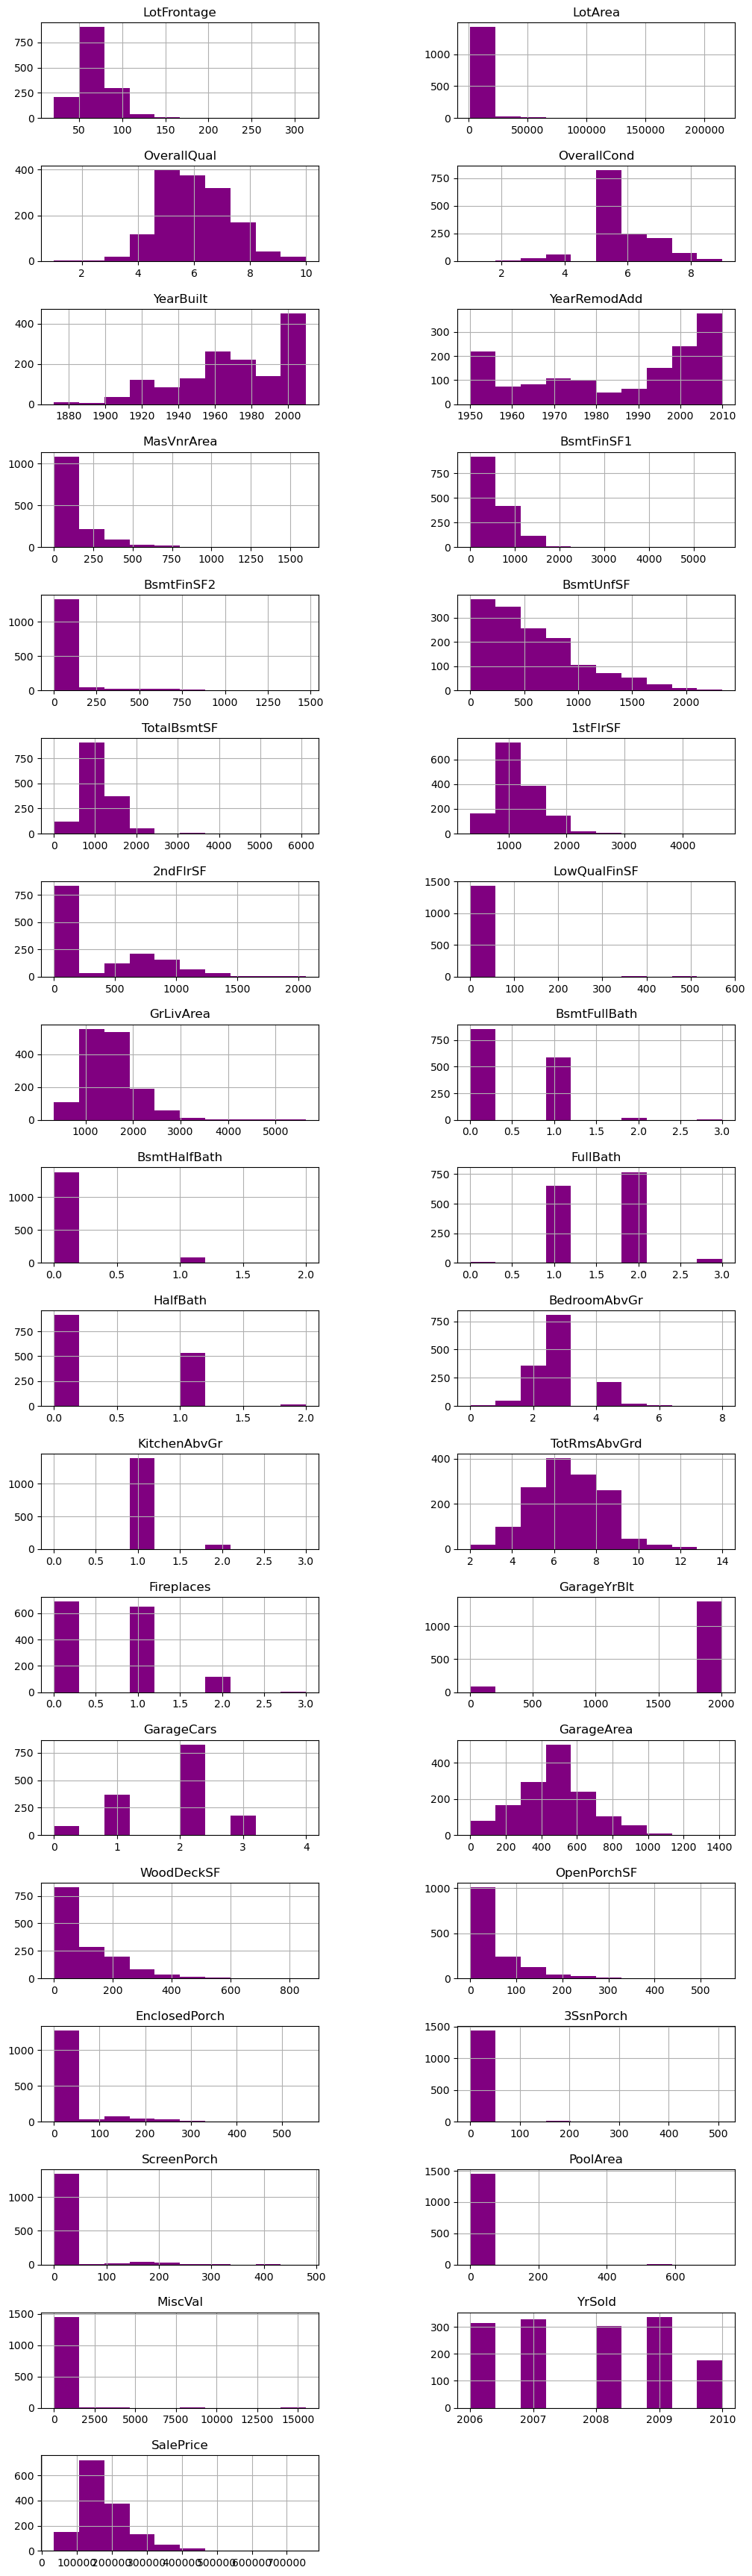

In [13]:
numerical = eda_ds.select_dtypes("int64")
numerical.hist(
    bins=10, figsize=(12, 44), color="purple", layout=(18, 2)
)
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

### Barplots

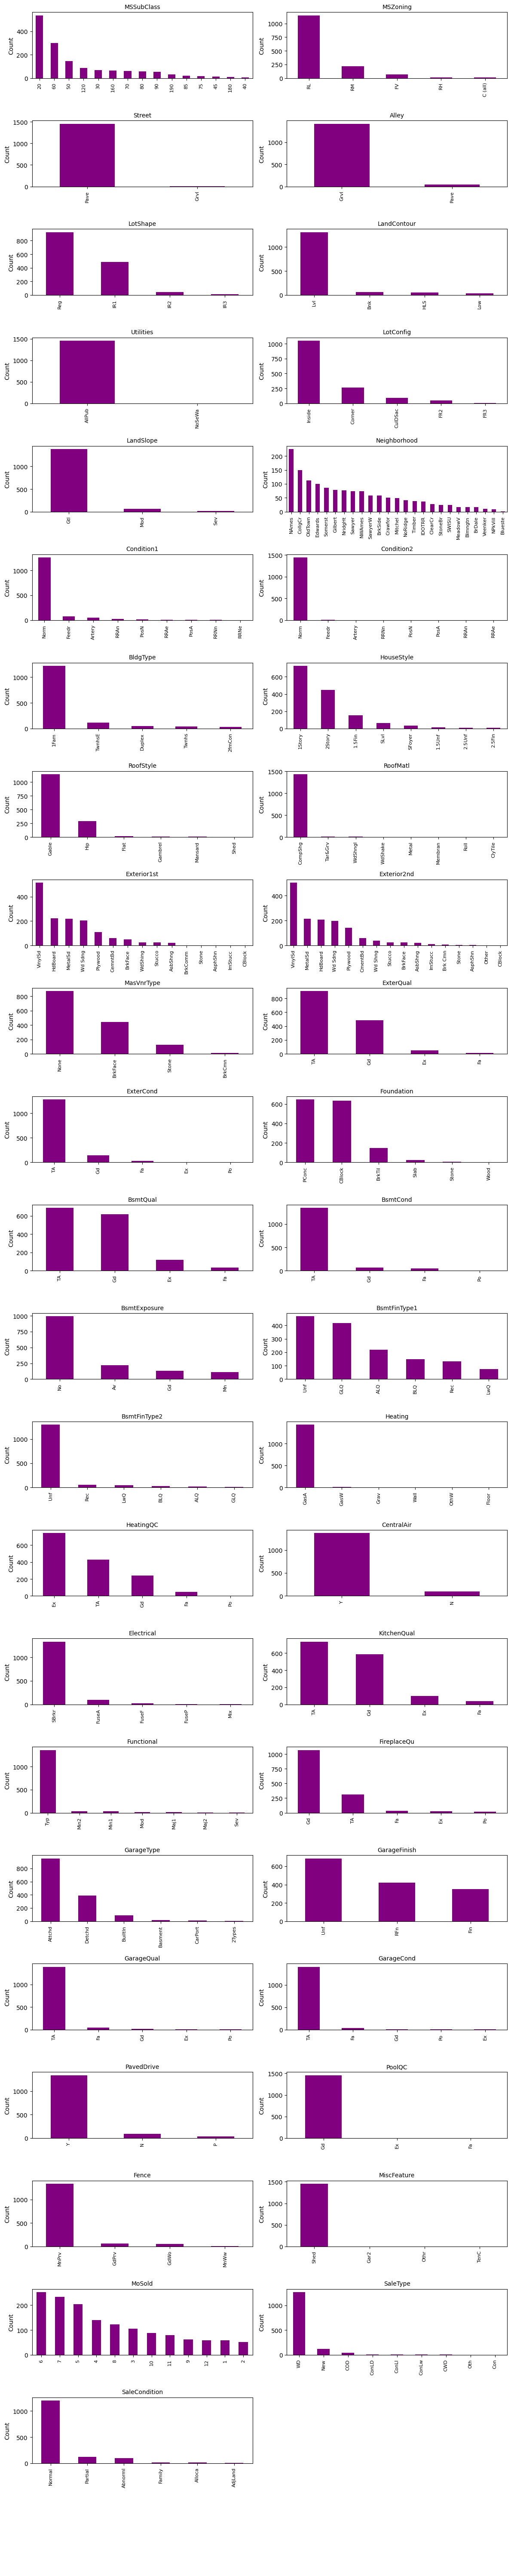

In [14]:
categorical = eda_ds.select_dtypes("object")

n_cols = 2
n_rows = 24

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 60))
axes = axes.flatten()

for ax, col in zip(axes, categorical.columns):
    vc = categorical[col].value_counts(dropna=False)

    vc.plot(kind='bar',  ax=ax, color='purple')
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.set_ylabel('Count')

# Hide any unused axes
for ax in axes[len(categorical.columns):]:
    ax.axis('off')
plt.subplots_adjust(hspace=0.8, wspace=0.8)
plt.tight_layout()
plt.show()


### Average Sale Price and Total Amount of Sales for Every Year

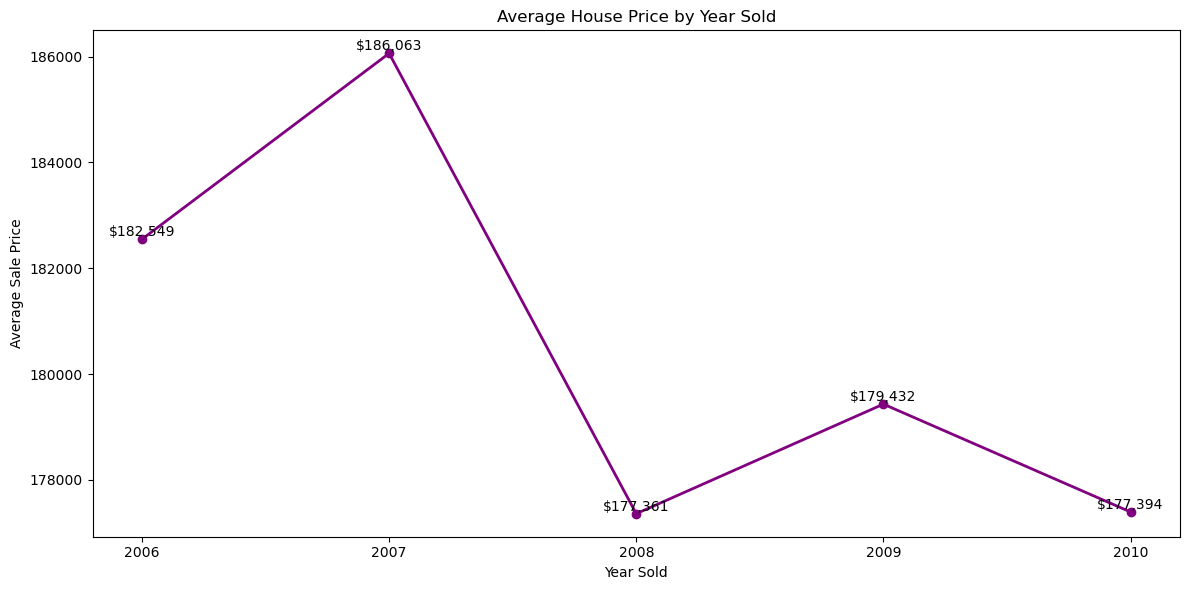

In [15]:
avg_price_by_year = eda_ds.groupby('YrSold')['SalePrice'].mean()

plt.figure(figsize=(12, 6))
ax = avg_price_by_year.plot(kind='line', marker='o', linewidth=2, color='purple')

plt.title('Average House Price by Year Sold')
plt.xlabel('Year Sold')
plt.ylabel('Average Sale Price')
plt.xticks(avg_price_by_year.index)  # Set x-ticks to be the years

for year, price in avg_price_by_year.items():
    ax.text(year, price, f'${price:,.0f}', ha='center', va='bottom')
plt.subplots_adjust(hspace=0.8, wspace=0.8)
plt.tight_layout()
plt.show()


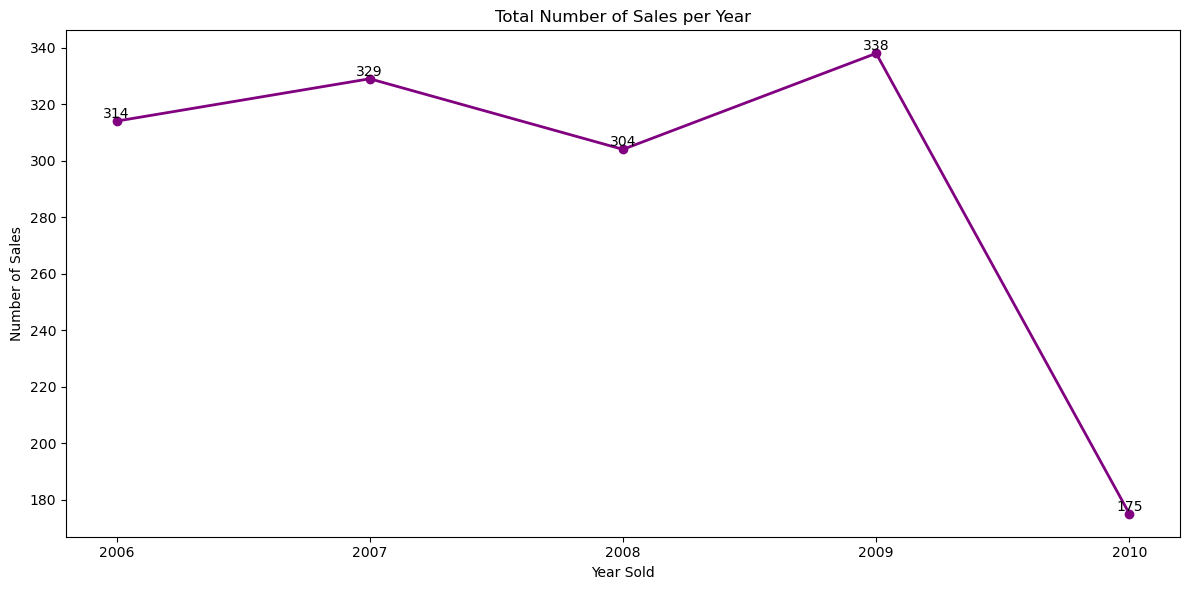

In [16]:
sales_per_year = eda_ds.groupby('YrSold').size()

plt.figure(figsize=(12, 6))
ax = sales_per_year.plot(kind='line', marker='o', linewidth=2, color='purple')

plt.title('Total Number of Sales per Year')
plt.xlabel('Year Sold')
plt.ylabel('Number of Sales')
plt.xticks(sales_per_year.index)  # Set x-ticks to be the years

for year, count in sales_per_year.items():
    ax.text(year, count, f'{count}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Average prices increase from 2006 to a peak in 2007, followed by a sharp decline in 2008. A partial recovery is observed in 2009, with prices decreasing again in 2010.\
Total number of sales increases from 2006 to 2007, declines in 2008, and then reaches its highest level in 2009. A substantial drop in the number of sales is observed in 2010.\
This noticeable volatility is timing closely with the global economic crisis of 2008.

### Correlation of Variables with SalePrice

To explore the relationship between numerical features and the target variable SalePrice, scatter plots are used to visualize potential correlations. These plots allow for the identification of linear or nonlinear trends between each numerical predictor and the sale price.\
Positive or negative correlations may be observed as diagonally increasing or decreasing patterns in the scatter plots, while weak or no correlation is indicated by a more diffuse or random distribution of points.

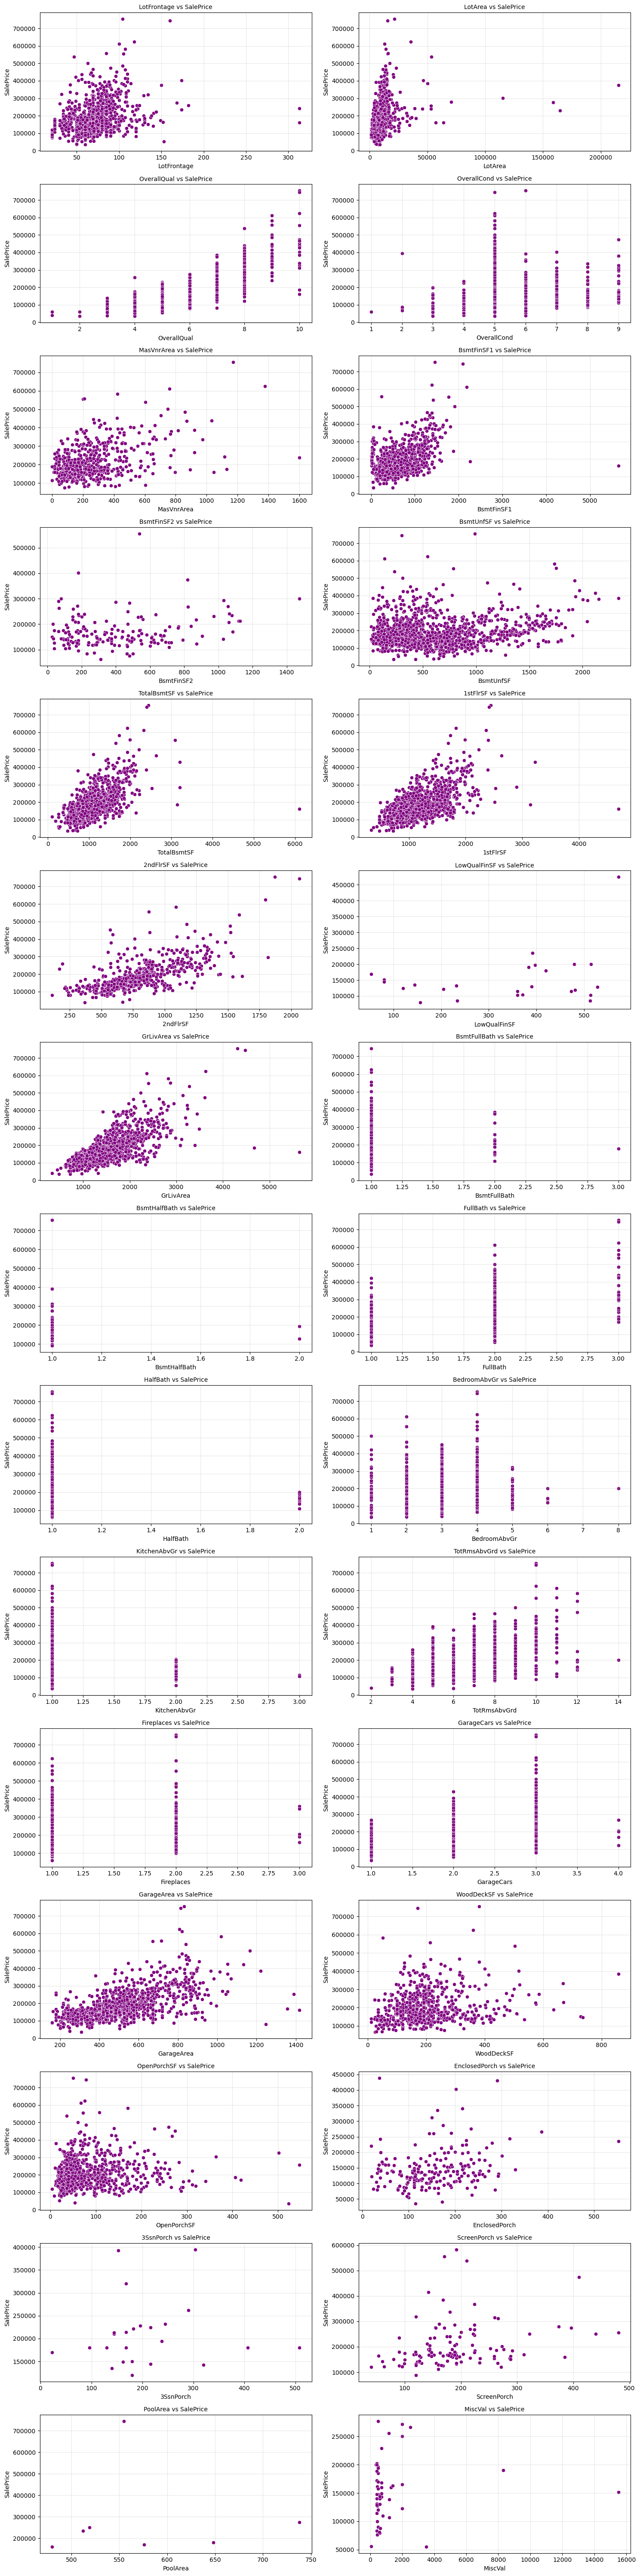

In [17]:
# Create scatterplots for all numerical variables against SalePrice
numerical_cols = eda_ds.select_dtypes(include=['int64']).columns.tolist()

numerical_cols.remove('YearBuilt')  # Remove  some variables
numerical_cols.remove('YearRemodAdd')
numerical_cols.remove('GarageYrBlt')
numerical_cols.remove('YrSold')
numerical_cols.remove('SalePrice')

n_cols = 2
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,  4* n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numerical_cols):
    subset = eda_ds[eda_ds[col] > 0]

    sns.scatterplot(
        data=subset,
        x=col,
        y='SalePrice',
        ax=ax,
        color='purple'
    )

    ax.set_title(f'{col} vs SalePrice', fontsize=10)
    ax.grid(alpha=0.3)

# Hide any unused axes
for ax in axes[len(numerical_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Variables LotFrontage, BSmtFinSF1, TotalBsmtSF, 1stFlrSF, 2ndFlrSF, GrLivArea, GarageArea seem to have considerable correlation.

I am going to use median house prices in correlation with 'year' variables - YearBuilt, YearRemodAdd, GarageYrBlt to reduce the influence of extreme values and outliers.

Median sales for 'year' variables:

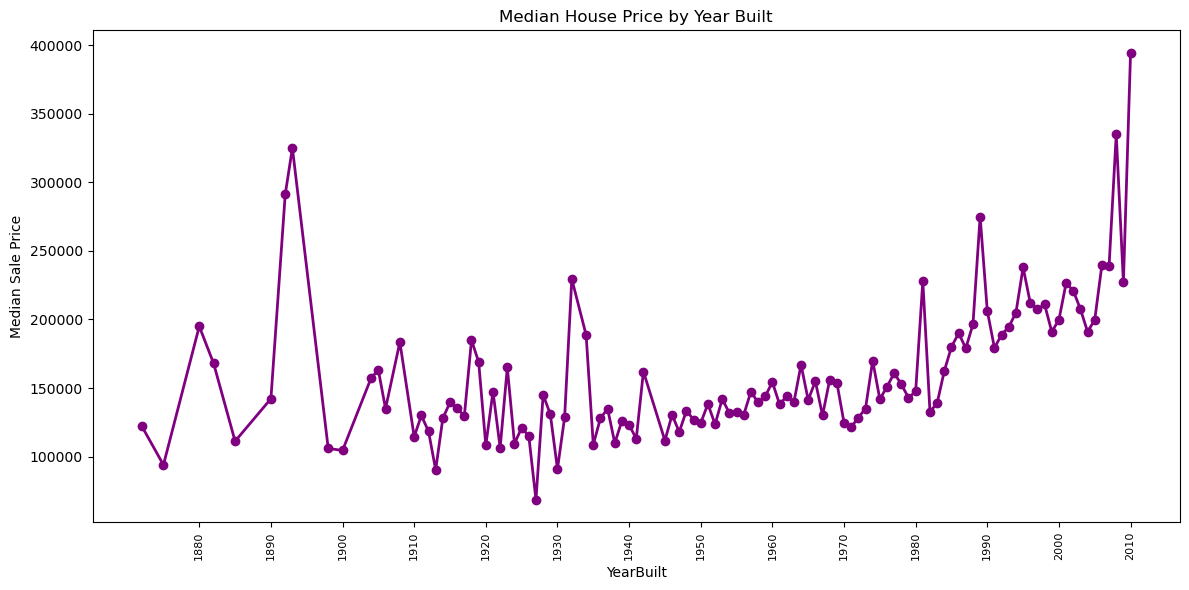

In [18]:
year_built_price = eda_ds.groupby('YearBuilt')['SalePrice'].median()
xticks = year_built_price.index[year_built_price.index % 10 == 0]
plt.figure(figsize=(12, 6))
ax = year_built_price.plot(kind='line', marker='o', linewidth=2, color='purple')

plt.title('Median House Price by Year Built')
plt.xlabel('YearBuilt')
plt.ylabel('Median Sale Price')
plt.xticks(xticks, rotation=90, fontsize=8)  # Set x-ticks to be the years
#plt.subplots_adjust(hspace=0.8, wspace=0.8)
plt.tight_layout()
plt.show()


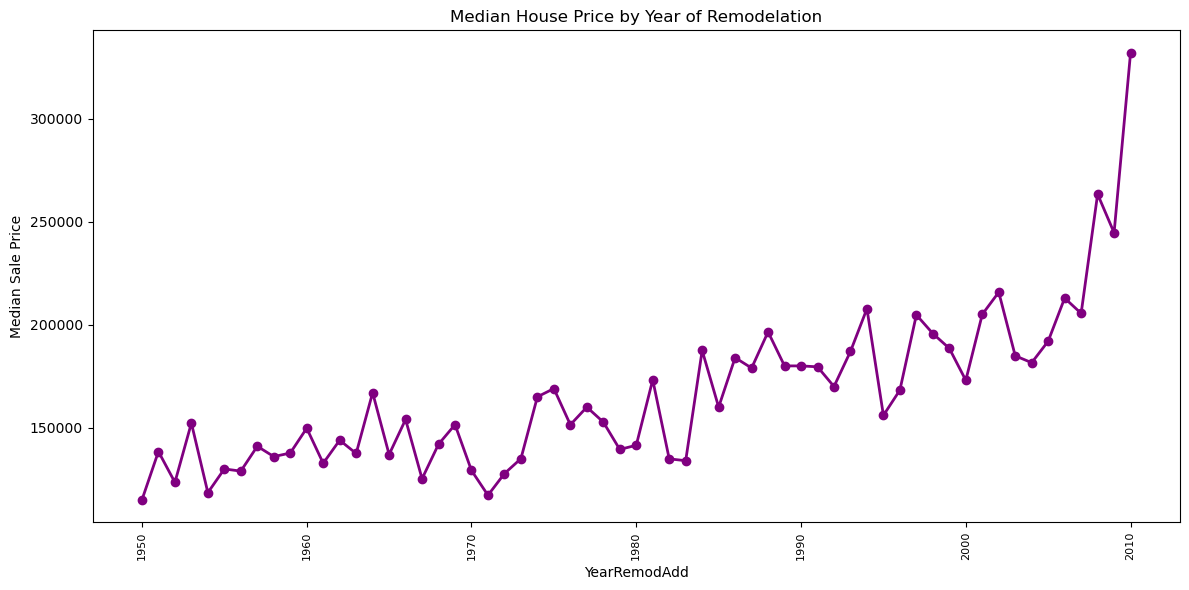

In [19]:
yr_remod_add_price=eda_ds.groupby('YearRemodAdd')['SalePrice'].median()
xticks = yr_remod_add_price.index[yr_remod_add_price.index % 10 == 0]
plt.figure(figsize=(12, 6))
ax = yr_remod_add_price.plot(kind='line', marker='o', linewidth=2, color='purple')

plt.title('Median House Price by Year of Remodelation')
plt.xlabel('YearRemodAdd')
plt.ylabel('Median Sale Price')
plt.xticks(xticks, rotation=90, fontsize=8)  # Set x-ticks to be the years
#plt.subplots_adjust(hspace=0.8, wspace=0.8)
plt.tight_layout()
plt.show()


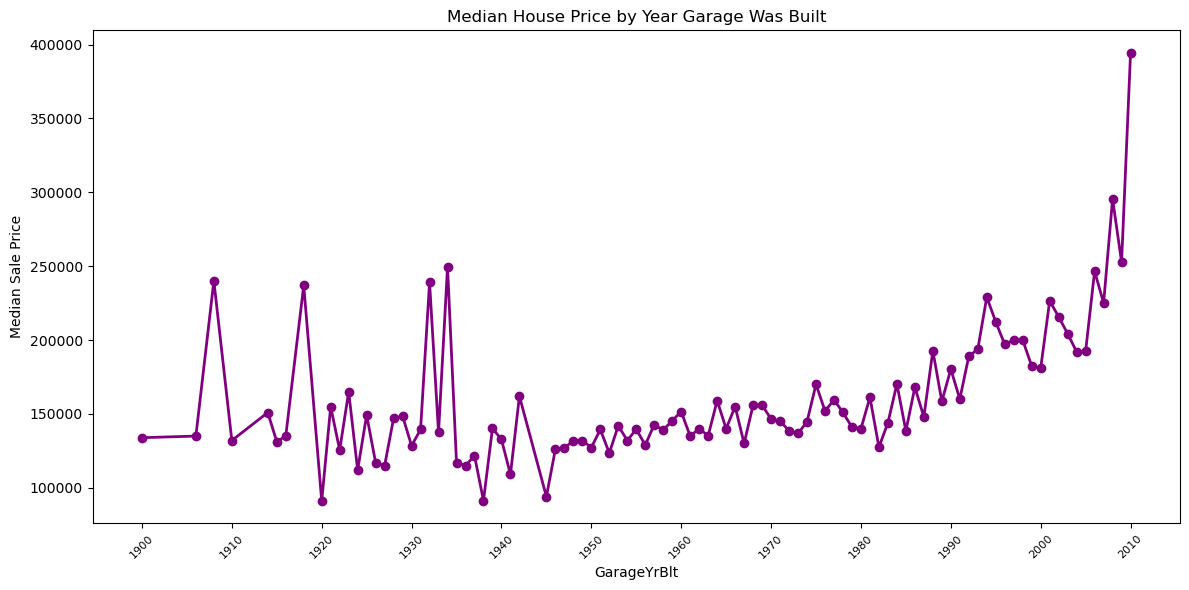

In [20]:
garage_yr_built_price = (
    eda_ds
        .dropna(subset=["GarageYrBlt"])
        .query("GarageYrBlt > 0")
        .groupby("GarageYrBlt")["SalePrice"]
        .median()
        .sort_index()
)

# X-ticks every 10 years
xticks = garage_yr_built_price.index[
    garage_yr_built_price.index % 10 == 0
]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(
    garage_yr_built_price.index,
    garage_yr_built_price.values,
    marker="o",
    linewidth=2,
    color="purple"
)

plt.title("Median House Price by Year Garage Was Built")
plt.xlabel("GarageYrBlt")
plt.ylabel("Median Sale Price")
plt.xticks(xticks, rotation=45, fontsize=8)

plt.tight_layout()
plt.show()


All 'year' variables show good correlation with SalePrice.

I am going to use box plots to examine the relationship between categorical variables and the target variable SalePrice. Boxplots provide a concise summary of the distribution of sale prices within each category, allowing for comparison of medians, variability, and the presence of outliers across groups.

Boxplots:

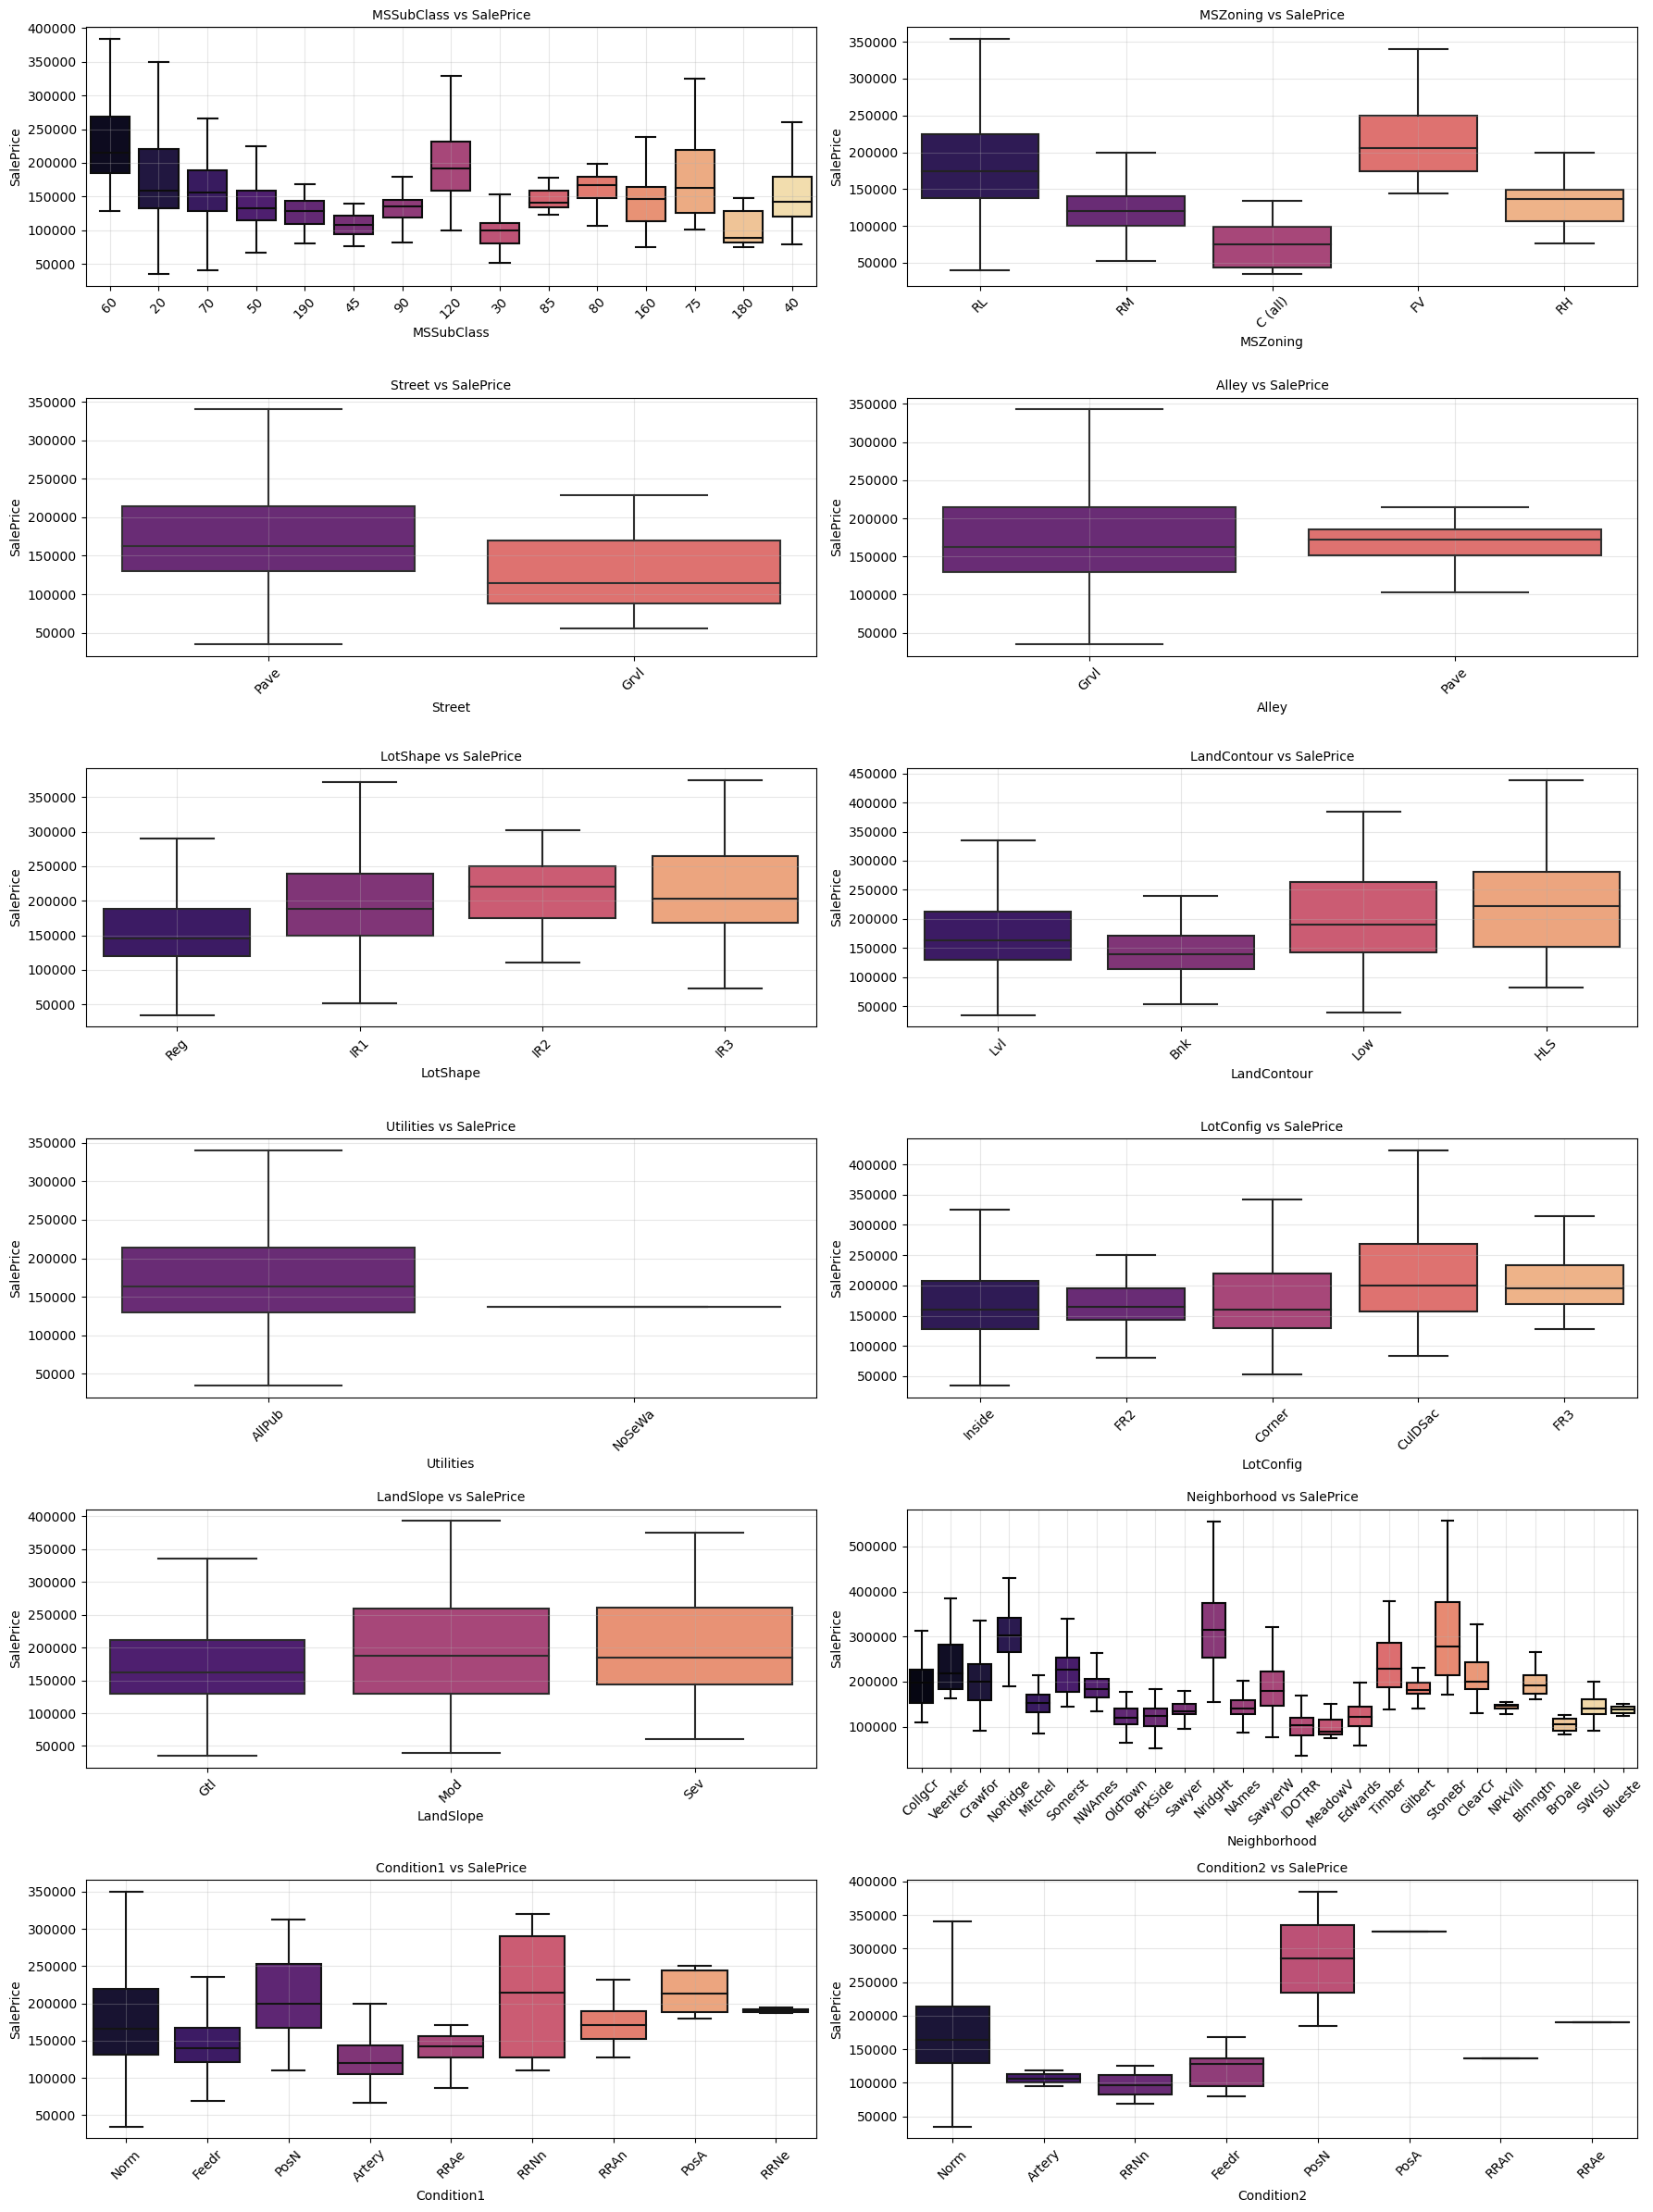

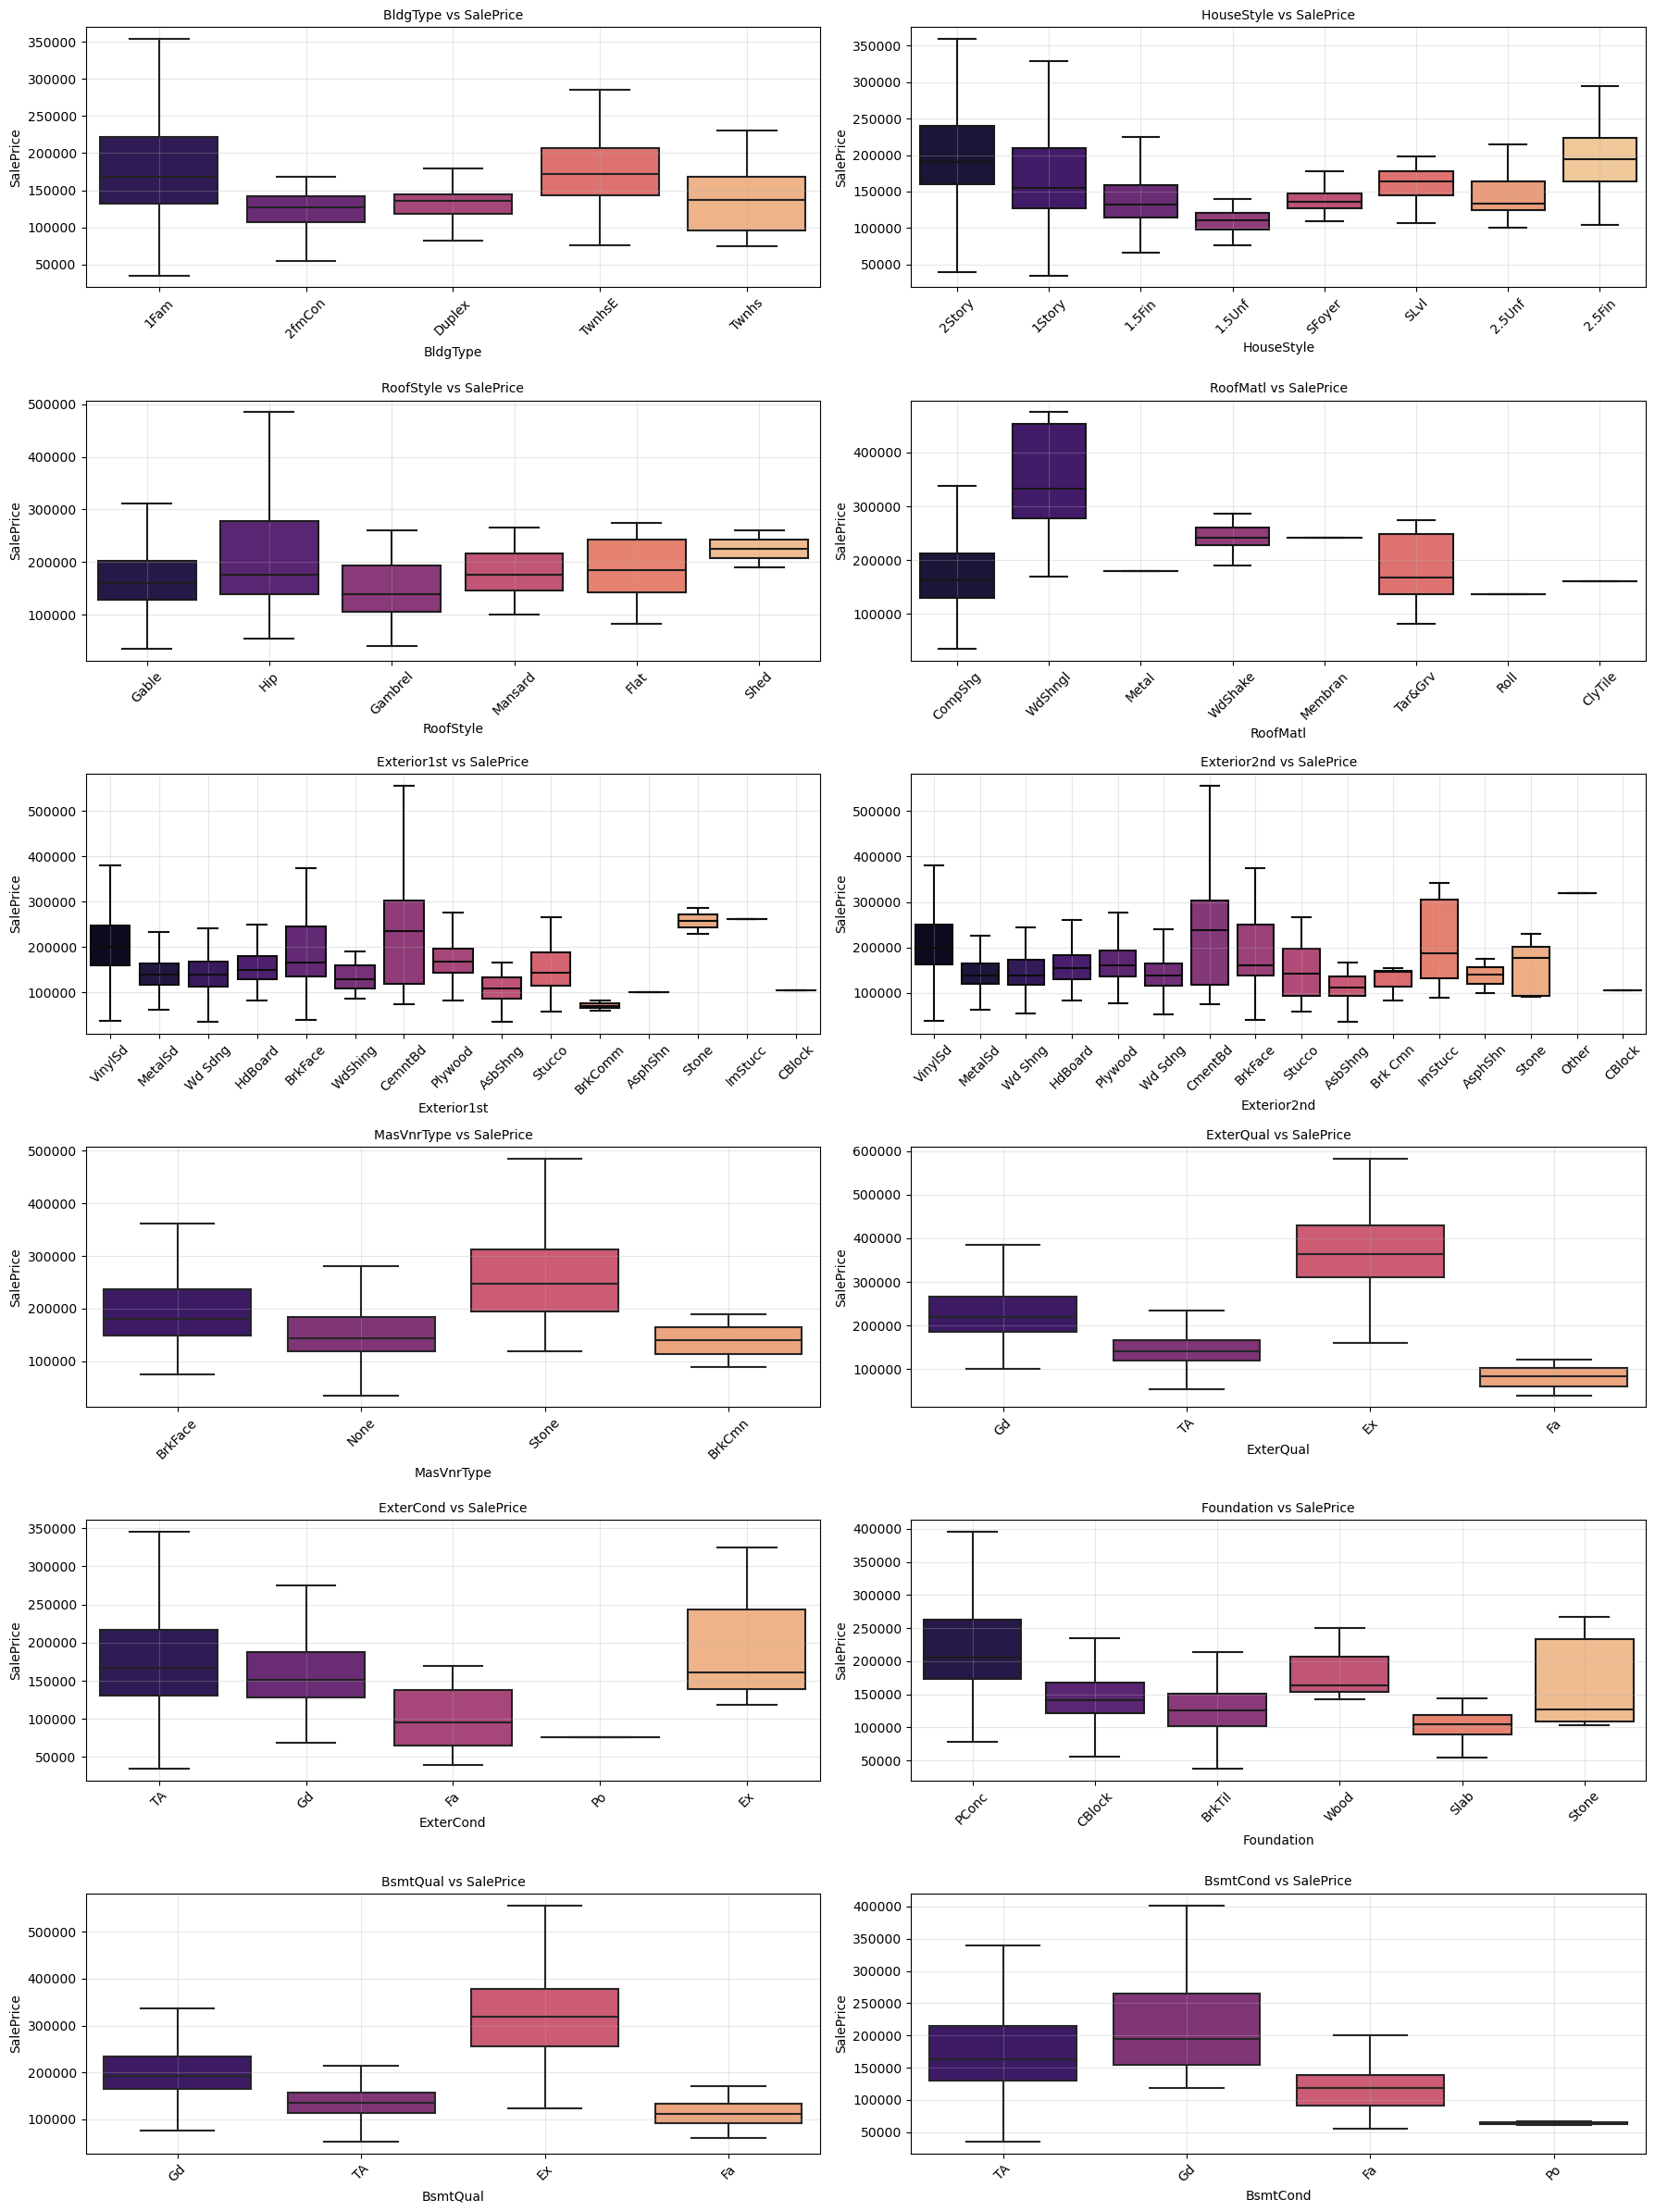

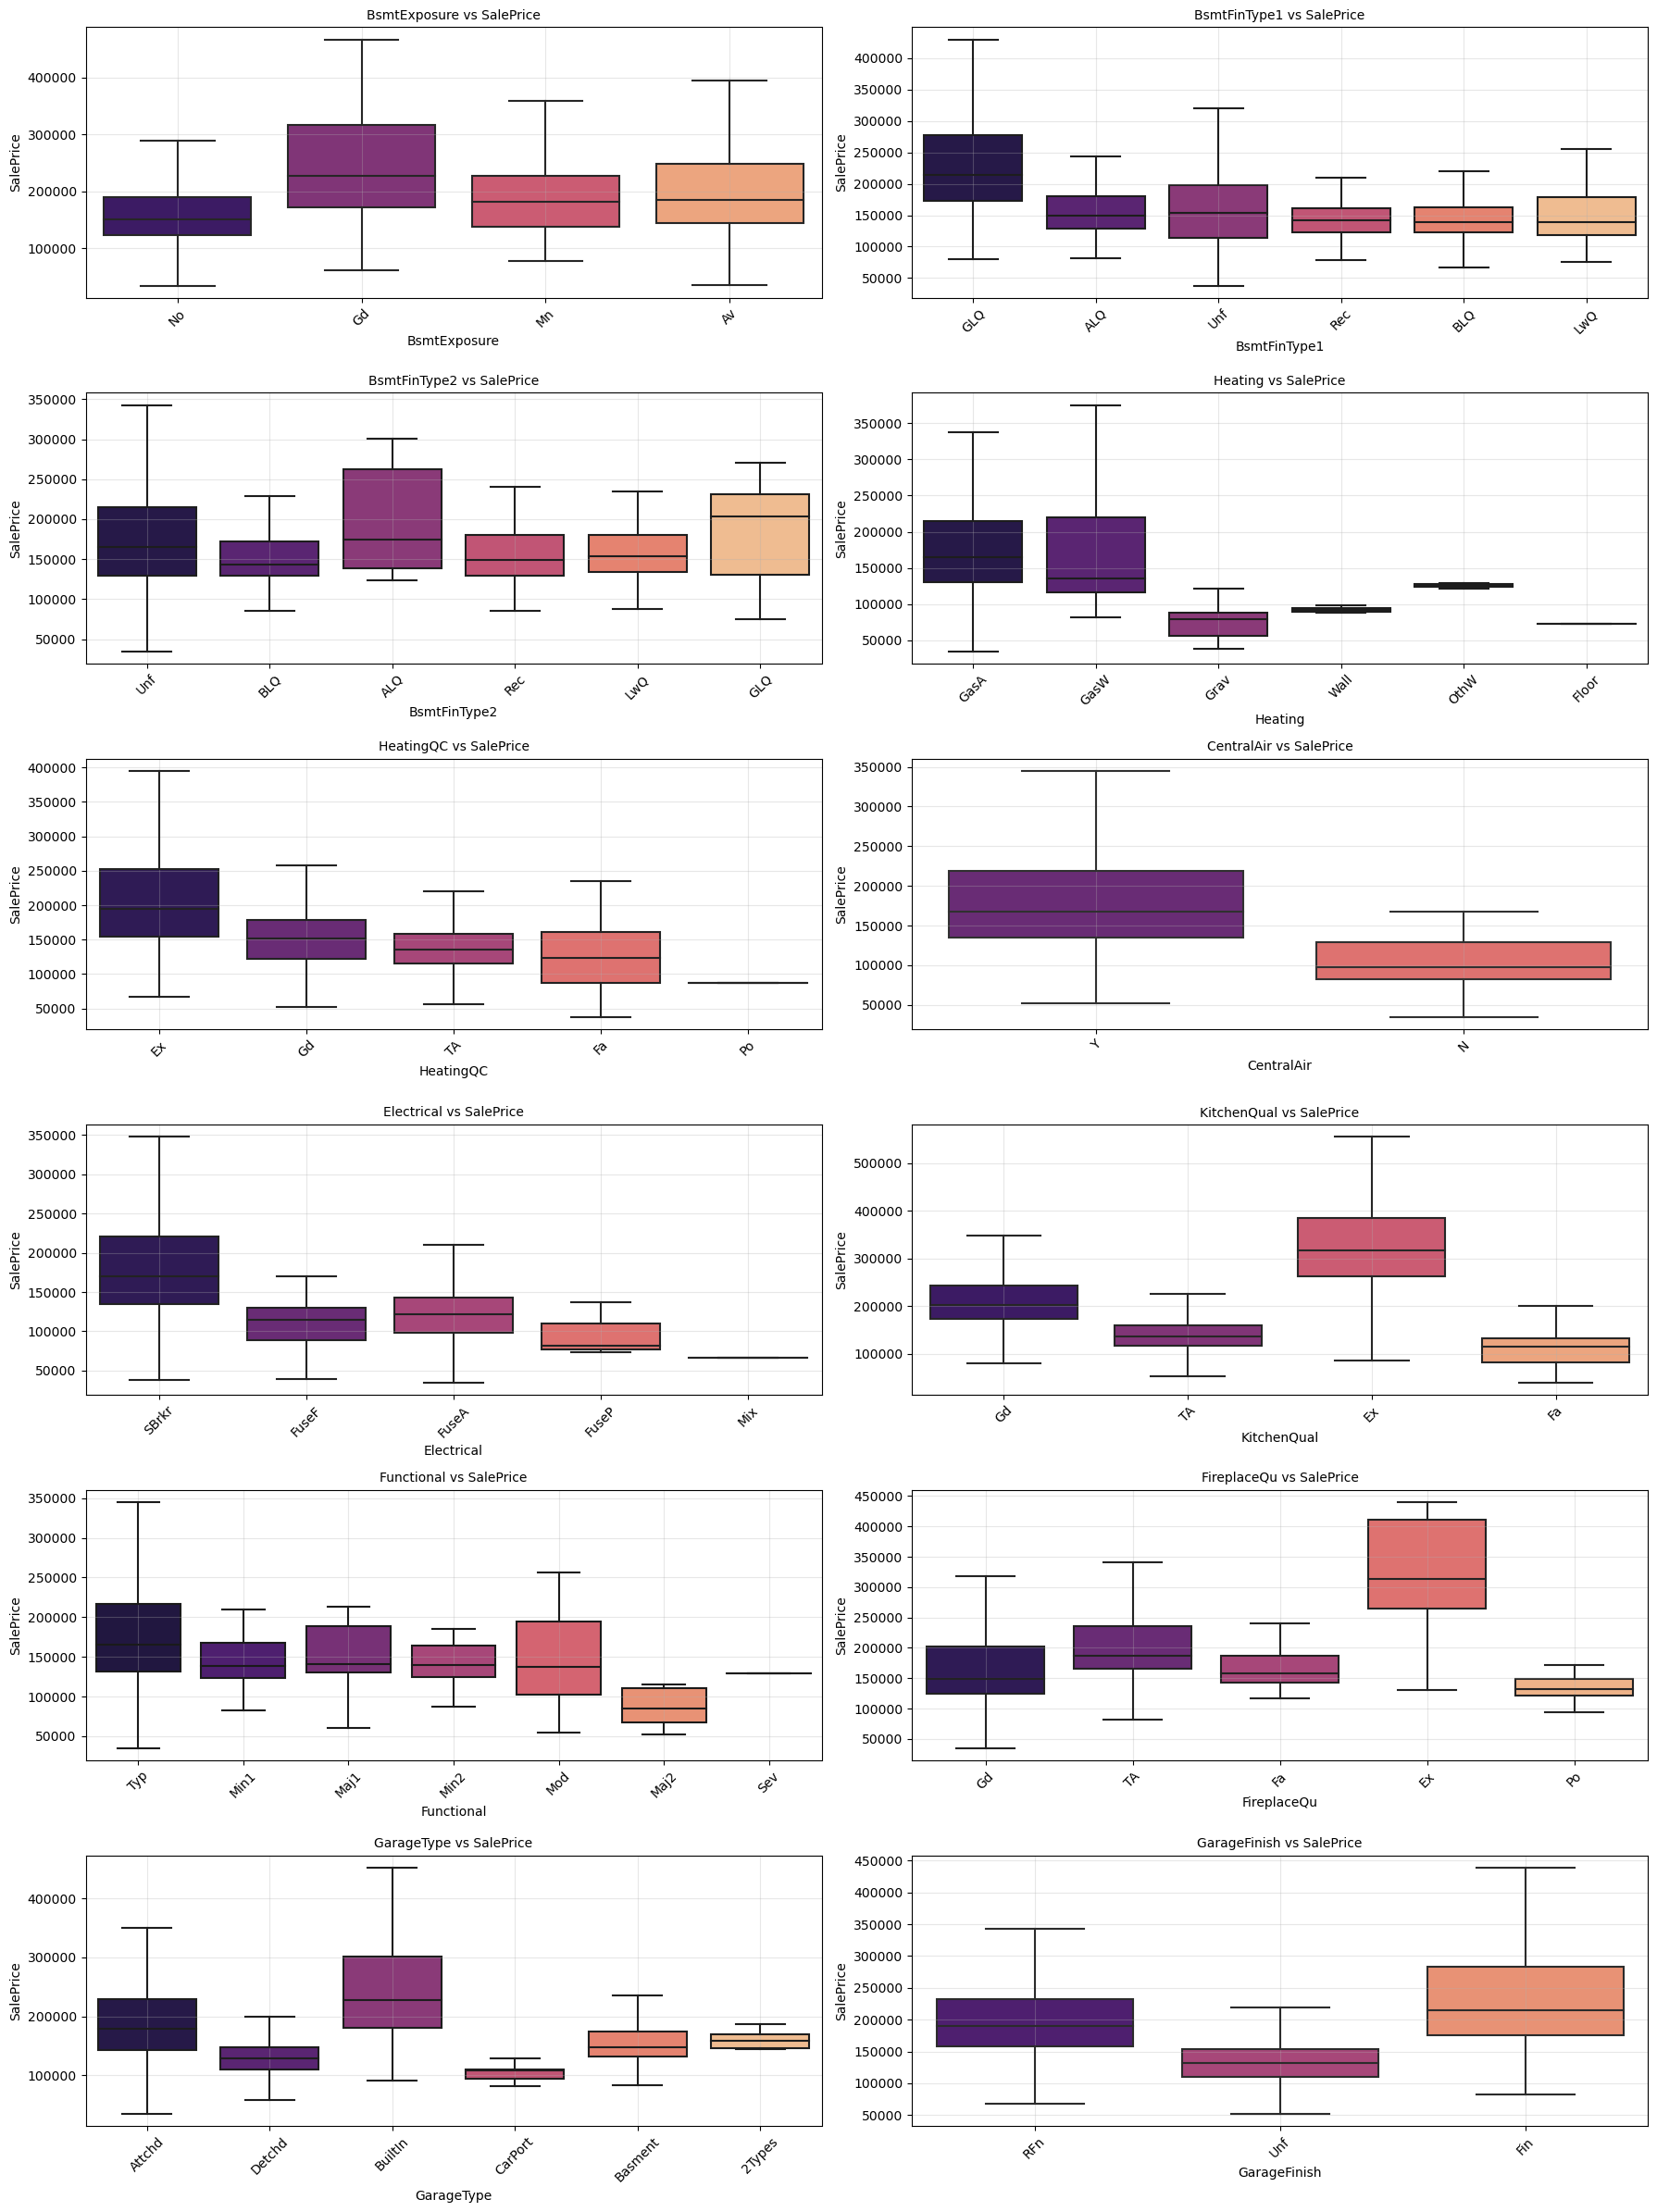

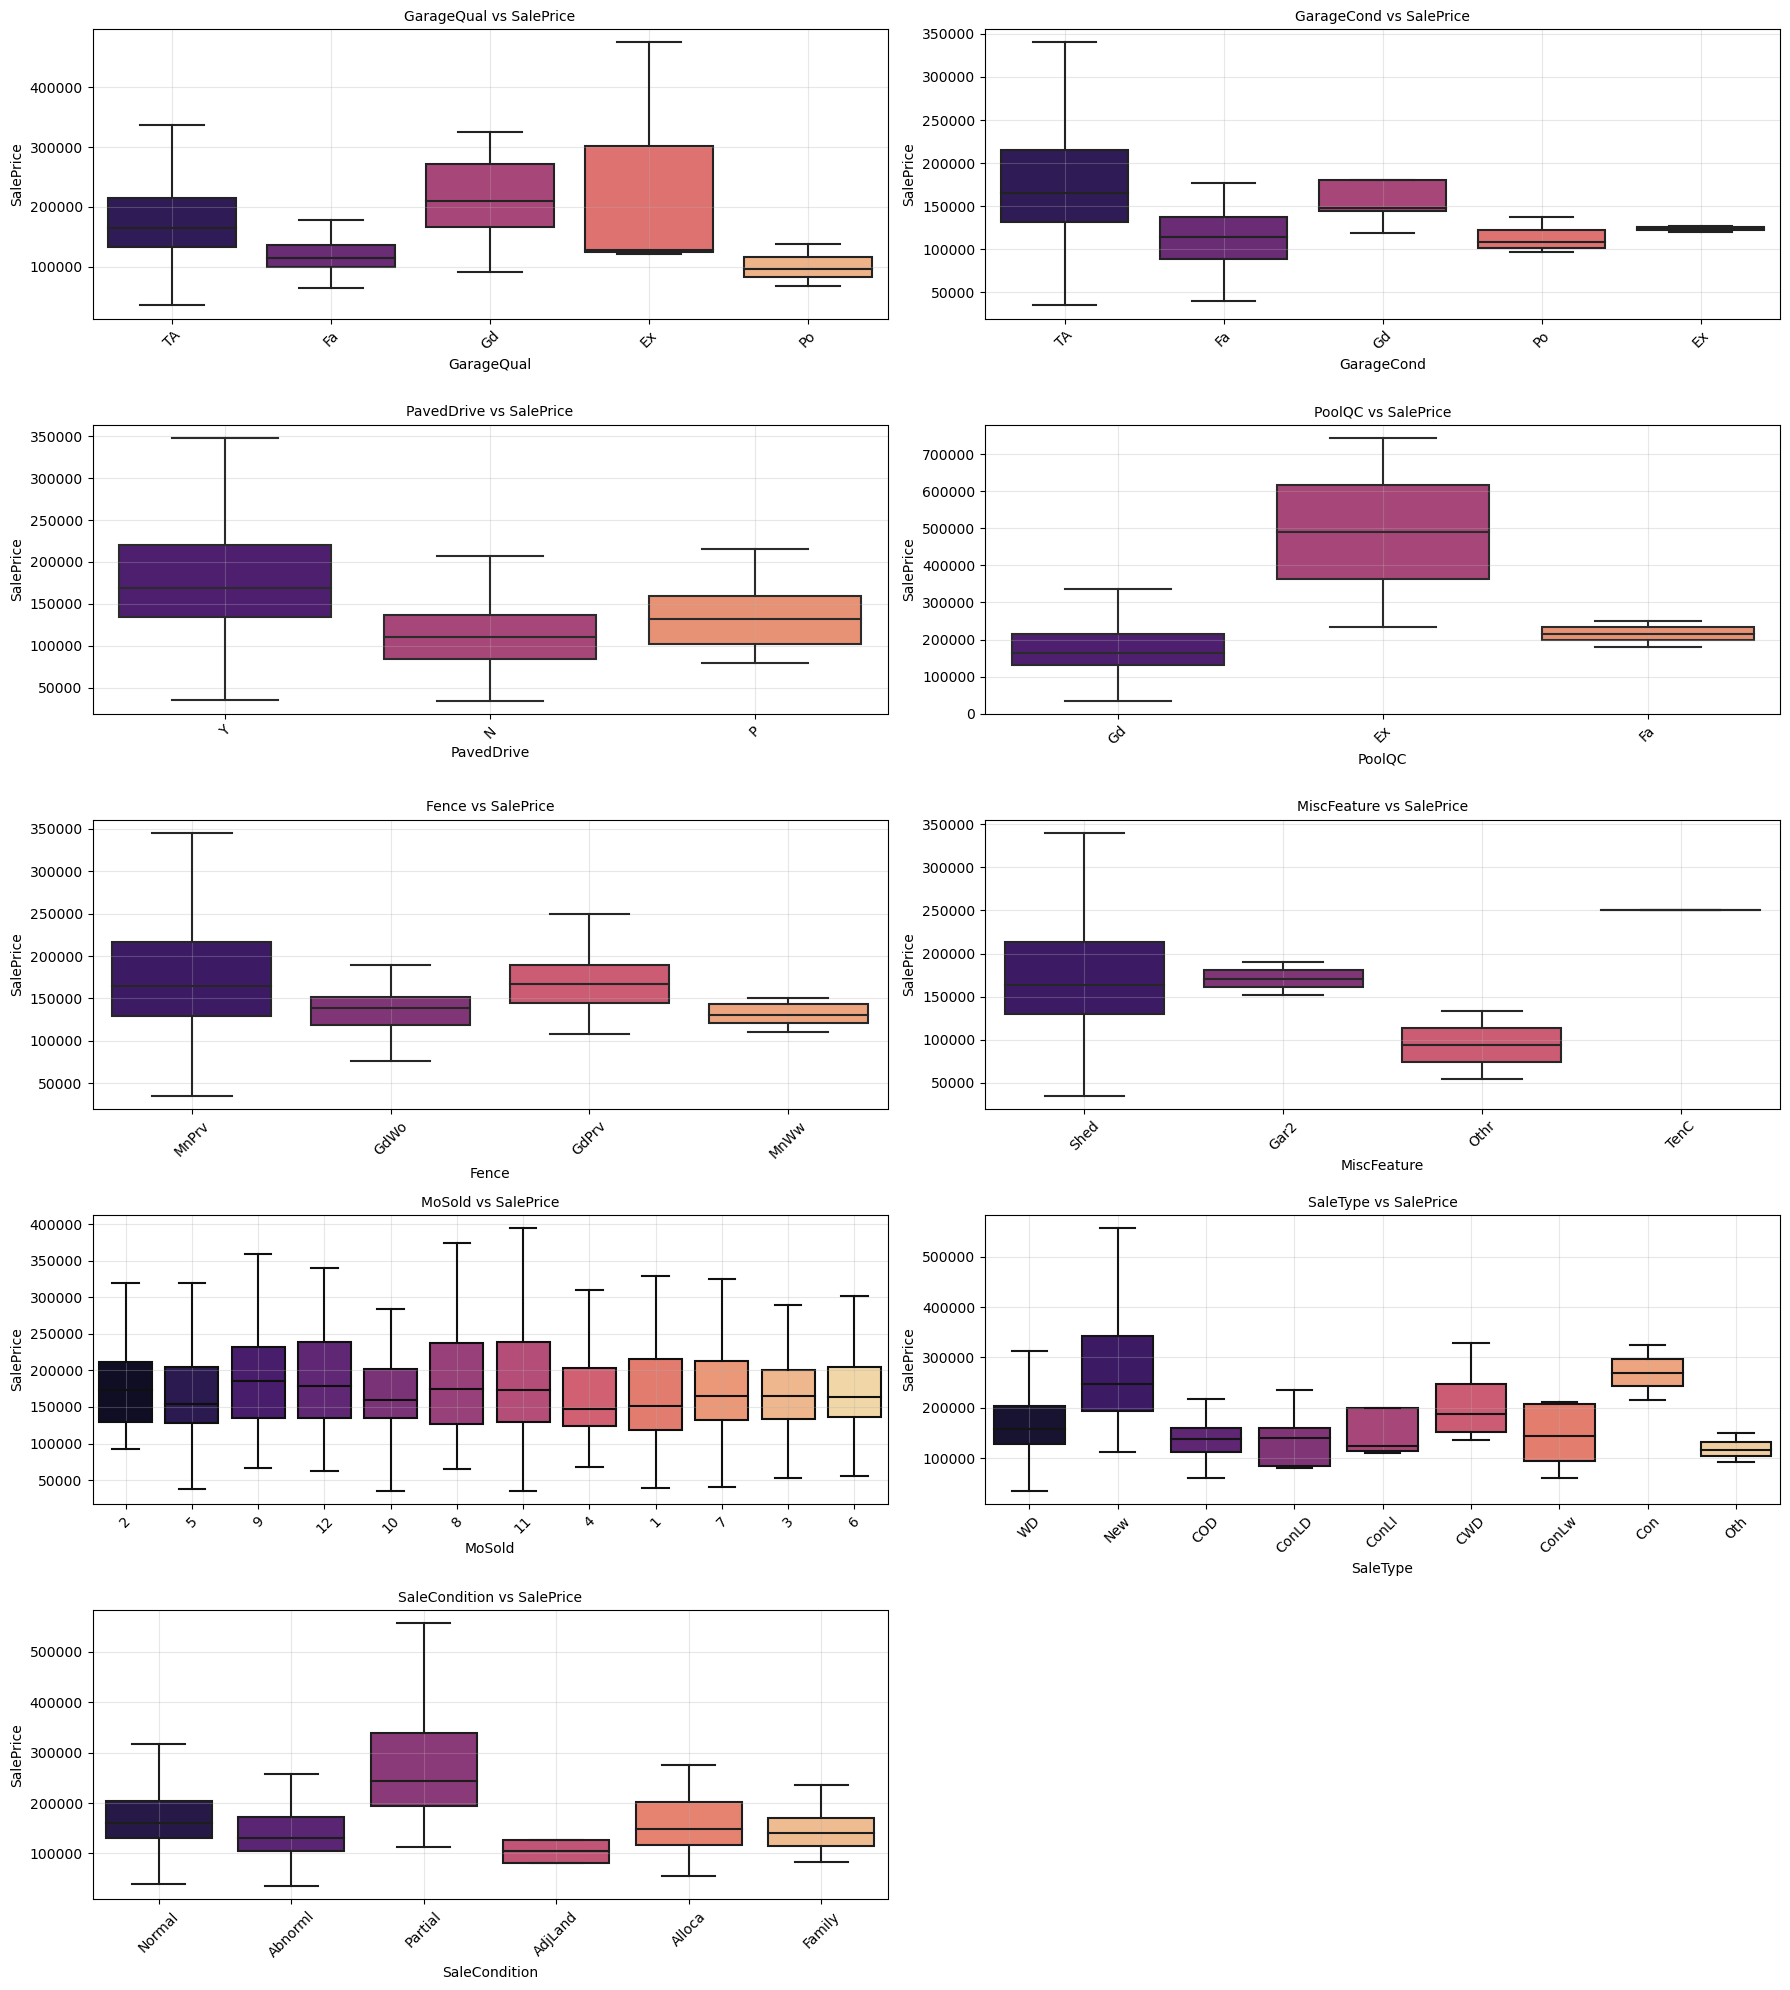

In [21]:

cat_cols = eda_ds.select_dtypes(include=["object"]).columns.tolist()

n_cols = 2
plots_per_fig = 12  # 12 plots per figure (6 rows x 2 cols)

for i in range(0, len(cat_cols), plots_per_fig):
    batch = cat_cols[i:i+plots_per_fig]
    n_rows = math.ceil(len(batch) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, batch):
        sns.boxplot(data=eda_ds, x=col, y="SalePrice", ax=ax, showfliers=False, palette="magma")
        ax.set_title(f"{col} vs SalePrice", fontsize=10)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)

    # turn off unused axes
    for ax in axes[len(batch):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


The box plots indicate that variables related to material quality, overall condition, number of rooms, number of fireplaces, and garage capacity are strongly associated with SalePrice.

## Preprocessing

In [ ]:
X = train_ds.drop("SalePrice", axis=1)
y = train_ds["SalePrice"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Log-transform target to reduce skew and improve linear regression assumptions

y_train = np.log1p(y_train)
y_val = np.log1p(y_val)

num_features = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_features = X_train.select_dtypes(include=["object"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])

In [23]:
from sklearn.linear_model import Ridge

# Ridge regression is a strong baseline for Ames because it stabilizes coefficients
# in the presence of multicollinearity (many correlated area/quality variables).
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=10))
])


## Model

In [24]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'L...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('regressor', Ridge(alpha=10))])

In [25]:
y_pred = model.predict(X_val)

# Evaluate on log scale (common for Ames / Kaggle)
rmse_log = np.sqrt(mean_squared_error(y_val, y_pred))
r2_log = r2_score(y_val, y_pred)

rmse_log, r2_log


(0.13609761185439992, 0.9007423941509539)

In [26]:
# Convert RMSE back to dollars for interpretability
rmse_dollars = np.sqrt(
    mean_squared_error(np.expm1(y_val), np.expm1(y_pred))
)
rmse_dollars


25059.579918088704

In [27]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coeffs = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coeffs
}).sort_values(by="coefficient", key=lambda s: s.abs(), ascending=False)

coef_df.head(20)


,feature,coefficient
124,cat__RoofMatl_ClyTile,-0.105091
85,cat__Neighborhood_StoneBr,0.093310
69,cat__Neighborhood_Crawfor,0.086183
101,cat__Condition2_PosN,-0.081143
3,num__OverallQual,0.074123
134,cat__Exterior1st_BrkFace,0.071486
262,cat__PoolQC_Gd,-0.071325
79,cat__Neighborhood_NridgHt,0.068351
232,cat__Functional_Typ,0.067202
73,cat__Neighborhood_MeadowV,-0.066741


In [28]:
coef_df.head(20)

,feature,coefficient
124,cat__RoofMatl_ClyTile,-0.105091
85,cat__Neighborhood_StoneBr,0.093310
69,cat__Neighborhood_Crawfor,0.086183
101,cat__Condition2_PosN,-0.081143
3,num__OverallQual,0.074123
134,cat__Exterior1st_BrkFace,0.071486
262,cat__PoolQC_Gd,-0.071325
79,cat__Neighborhood_NridgHt,0.068351
232,cat__Functional_Typ,0.067202
73,cat__Neighborhood_MeadowV,-0.066741


In [29]:
# Fit final model on full training data (log-transformed target)
model.fit(X, np.log1p(y))


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'L...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('regressor', Ridge(alpha=10))])

In [30]:
# Predict on test set and convert back to dollar scale
test_preds = np.expm1(model.predict(test_ds))
test_preds[:10]


array([114285.1489002 , 145754.56188728, 170629.29493653, 193048.98596656,
       198054.24786977, 168311.2480337 , 185084.5154406 , 161318.78336902,
       189411.39899772, 121920.69585632])

In [31]:
# Create submission dataframe (Id + SalePrice)
submission = pd.DataFrame({
    "Id": test_ds["Id"],
    "SalePrice": test_preds
})
submission.head()


KeyError: 'Id'

----
# End

---
# Data Description
MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM	Residential Medium Density
	
LotFrontage: Linear feet of street connected to property

LotArea: Lot size in square feet

Street: Type of road access to property

       Grvl	Gravel	
       Pave	Paved
       	
Alley: Type of alley access to property

       Grvl	Gravel
       Pave	Paved
       NA 	No alley access
		
LotShape: General shape of property

       Reg	Regular	
       IR1	Slightly irregular
       IR2	Moderately Irregular
       IR3	Irregular
       
LandContour: Flatness of the property

       Lvl	Near Flat/Level	
       Bnk	Banked - Quick and significant rise from street grade to building
       HLS	Hillside - Significant slope from side to side
       Low	Depression
		
Utilities: Type of utilities available
		
       AllPub	All public Utilities (E,G,W,& S)	
       NoSewr	Electricity, Gas, and Water (Septic Tank)
       NoSeWa	Electricity and Gas Only
       ELO	Electricity only	
	
LotConfig: Lot configuration

       Inside	Inside lot
       Corner	Corner lot
       CulDSac	Cul-de-sac
       FR2	Frontage on 2 sides of property
       FR3	Frontage on 3 sides of property
	
LandSlope: Slope of property
		
       Gtl	Gentle slope
       Mod	Moderate Slope	
       Sev	Severe Slope
	
Neighborhood: Physical locations within Ames city limits

       Blmngtn	Bloomington Heights
       Blueste	Bluestem
       BrDale	Briardale
       BrkSide	Brookside
       ClearCr	Clear Creek
       CollgCr	College Creek
       Crawfor	Crawford
       Edwards	Edwards
       Gilbert	Gilbert
       IDOTRR	Iowa DOT and Rail Road
       MeadowV	Meadow Village
       Mitchel	Mitchell
       Names	North Ames
       NoRidge	Northridge
       NPkVill	Northpark Villa
       NridgHt	Northridge Heights
       NWAmes	Northwest Ames
       OldTown	Old Town
       SWISU	South & West of Iowa State University
       Sawyer	Sawyer
       SawyerW	Sawyer West
       Somerst	Somerset
       StoneBr	Stone Brook
       Timber	Timberland
       Veenker	Veenker
			
Condition1: Proximity to various conditions
	
       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street	
       Norm	Normal	
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to postive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad
	
Condition2: Proximity to various conditions (if more than one is present)
		
       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street	
       Norm	Normal	
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to postive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad
	
BldgType: Type of dwelling
		
       1Fam	Single-family Detached	
       2FmCon	Two-family Conversion; originally built as one-family dwelling
       Duplx	Duplex
       TwnhsE	Townhouse End Unit
       TwnhsI	Townhouse Inside Unit
	
HouseStyle: Style of dwelling
	
       1Story	One story
       1.5Fin	One and one-half story: 2nd level finished
       1.5Unf	One and one-half story: 2nd level unfinished
       2Story	Two story
       2.5Fin	Two and one-half story: 2nd level finished
       2.5Unf	Two and one-half story: 2nd level unfinished
       SFoyer	Split Foyer
       SLvl	Split Level
	
OverallQual: Rates the overall material and finish of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average
       5	Average
       4	Below Average
       3	Fair
       2	Poor
       1	Very Poor
	
OverallCond: Rates the overall condition of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average	
       5	Average
       4	Below Average	
       3	Fair
       2	Poor
       1	Very Poor
		
YearBuilt: Original construction date

YearRemodAdd: Remodel date (same as construction date if no remodeling or additions)

RoofStyle: Type of roof

       Flat	Flat
       Gable	Gable
       Gambrel	Gabrel (Barn)
       Hip	Hip
       Mansard	Mansard
       Shed	Shed
		
RoofMatl: Roof material

       ClyTile	Clay or Tile
       CompShg	Standard (Composite) Shingle
       Membran	Membrane
       Metal	Metal
       Roll	Roll
       Tar&Grv	Gravel & Tar
       WdShake	Wood Shakes
       WdShngl	Wood Shingles
		
Exterior1st: Exterior covering on house

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	Other
       Plywood	Plywood
       PreCast	PreCast	
       Stone	Stone
       Stucco	Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles
	
Exterior2nd: Exterior covering on house (if more than one material)

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	Other
       Plywood	Plywood
       PreCast	PreCast
       Stone	Stone
       Stucco	Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles
	
MasVnrType: Masonry veneer type

       BrkCmn	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       None	None
       Stone	Stone
	
MasVnrArea: Masonry veneer area in square feet

ExterQual: Evaluates the quality of the material on the exterior 
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
ExterCond: Evaluates the present condition of the material on the exterior
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
Foundation: Type of foundation
		
       BrkTil	Brick & Tile
       CBlock	Cinder Block
       PConc	Poured Contrete	
       Slab	Slab
       Stone	Stone
       Wood	Wood
		
BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)	
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches
       NA	No Basement
		
BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement
	
BsmtExposure: Refers to walkout or garden level walls

       Gd	Good Exposure
       Av	Average Exposure (split levels or foyers typically score average or above)	
       Mn	Mimimum Exposure
       No	No Exposure
       NA	No Basement
	
BsmtFinType1: Rating of basement finished area

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement
		
BsmtFinSF1: Type 1 finished square feet

BsmtFinType2: Rating of basement finished area (if multiple types)

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement

BsmtFinSF2: Type 2 finished square feet

BsmtUnfSF: Unfinished square feet of basement area

TotalBsmtSF: Total square feet of basement area

Heating: Type of heating
		
       Floor	Floor Furnace
       GasA	Gas forced warm air furnace
       GasW	Gas hot water or steam heat
       Grav	Gravity furnace	
       OthW	Hot water or steam heat other than gas
       Wall	Wall furnace
		
HeatingQC: Heating quality and condition

       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
CentralAir: Central air conditioning

       N	No
       Y	Yes
		
Electrical: Electrical system

       SBrkr	Standard Circuit Breakers & Romex
       FuseA	Fuse Box over 60 AMP and all Romex wiring (Average)	
       FuseF	60 AMP Fuse Box and mostly Romex wiring (Fair)
       FuseP	60 AMP Fuse Box and mostly knob & tube wiring (poor)
       Mix	Mixed
		
1stFlrSF: First Floor square feet
 
2ndFlrSF: Second floor square feet

LowQualFinSF: Low quality finished square feet (all floors)

GrLivArea: Above grade (ground) living area square feet

BsmtFullBath: Basement full bathrooms

BsmtHalfBath: Basement half bathrooms

FullBath: Full bathrooms above grade

HalfBath: Half baths above grade

Bedroom: Bedrooms above grade (does NOT include basement bedrooms)

Kitchen: Kitchens above grade

KitchenQual: Kitchen quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       	
TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)

Functional: Home functionality (Assume typical unless deductions are warranted)

       Typ	Typical Functionality
       Min1	Minor Deductions 1
       Min2	Minor Deductions 2
       Mod	Moderate Deductions
       Maj1	Major Deductions 1
       Maj2	Major Deductions 2
       Sev	Severely Damaged
       Sal	Salvage only
		
Fireplaces: Number of fireplaces

FireplaceQu: Fireplace quality

       Ex	Excellent - Exceptional Masonry Fireplace
       Gd	Good - Masonry Fireplace in main level
       TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       Fa	Fair - Prefabricated Fireplace in basement
       Po	Poor - Ben Franklin Stove
       NA	No Fireplace
		
GarageType: Garage location
		
       2Types	More than one type of garage
       Attchd	Attached to home
       Basment	Basement Garage
       BuiltIn	Built-In (Garage part of house - typically has room above garage)
       CarPort	Car Port
       Detchd	Detached from home
       NA	No Garage
		
GarageYrBlt: Year garage was built
		
GarageFinish: Interior finish of the garage

       Fin	Finished
       RFn	Rough Finished	
       Unf	Unfinished
       NA	No Garage
		
GarageCars: Size of garage in car capacity

GarageArea: Size of garage in square feet

GarageQual: Garage quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage
		
GarageCond: Garage condition

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage
		
PavedDrive: Paved driveway

       Y	Paved 
       P	Partial Pavement
       N	Dirt/Gravel
		
WoodDeckSF: Wood deck area in square feet

OpenPorchSF: Open porch area in square feet

EnclosedPorch: Enclosed porch area in square feet

3SsnPorch: Three season porch area in square feet

ScreenPorch: Screen porch area in square feet

PoolArea: Pool area in square feet

PoolQC: Pool quality
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       NA	No Pool
		
Fence: Fence quality
		
       GdPrv	Good Privacy
       MnPrv	Minimum Privacy
       GdWo	Good Wood
       MnWw	Minimum Wood/Wire
       NA	No Fence
	
MiscFeature: Miscellaneous feature not covered in other categories
		
       Elev	Elevator
       Gar2	2nd Garage (if not described in garage section)
       Othr	Other
       Shed	Shed (over 100 SF)
       TenC	Tennis Court
       NA	None
		
MiscVal: $Value of miscellaneous feature

MoSold: Month Sold (MM)

YrSold: Year Sold (YYYY)

SaleType: Type of sale
		
       WD 	Warranty Deed - Conventional
       CWD	Warranty Deed - Cash
       VWD	Warranty Deed - VA Loan
       New	Home just constructed and sold
       COD	Court Officer Deed/Estate
       Con	Contract 15% Down payment regular terms
       ConLw	Contract Low Down payment and low interest
       ConLI	Contract Low Interest
       ConLD	Contract Low Down
       Oth	Other
		
SaleCondition: Condition of sale

       Normal	Normal Sale
       Abnorml	Abnormal Sale -  trade, foreclosure, short sale
       AdjLand	Adjoining Land Purchase
       Alloca	Allocation - two linked properties with separate deeds, typically condo with a garage unit	
       Family	Sale between family members
       Partial	Home was not completed when last assessed (associated with New Homes)
